In [1]:
# imports
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# configurations
RESULTS_DIR = Path("results")

parametersets = [
    "sha2-128s",
    "sha2-128f",
    "sha2-192s",
    "sha2-192f",
    "sha2-256s",
    "sha2-256f",
    "shake-128s",
    "shake-128f",
    "shake-192s",
    "shake-192f",
    "shake-256s",
    "shake-256f",
]

implementations = [
    "jasmin_ref",
    "c_ref",
]

actions = [
    "keygen",
    "sign",
    "verify",
]

In [3]:
# load cycle measurements from a text file

def load_cycles(filepath):
    """
    Load integer cycle measurements from a text file.

    Expected file format:
        one integer per line

    Returns:
        numpy array of integers
    """

    cycles = []

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()

            # skip empty lines
            if not line:
                continue

            cycles.append(int(line))

    return np.array(cycles, dtype=np.int64)

In [4]:
# load all benchmark data

benchmark_data = {}

for impl in implementations:
    benchmark_data[impl] = {}

    for action in actions:

        filename = f"{impl}_{action}.txt"
        filepath = RESULTS_DIR / filename

        if not filepath.exists():
            print(f"[WARNING] Missing file: {filepath}")
            continue

        cycles = load_cycles(filepath)

        benchmark_data[impl][action] = cycles

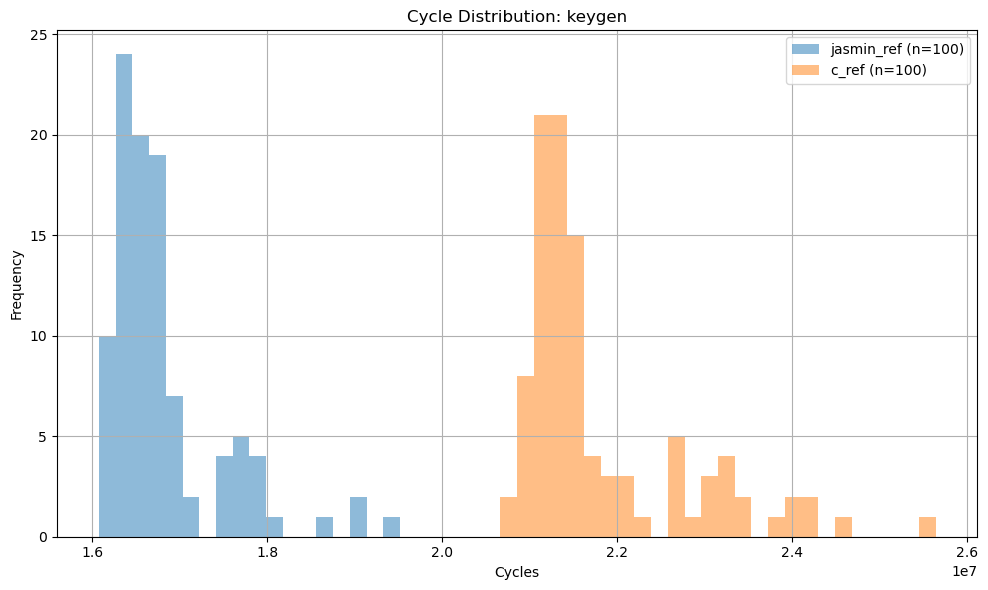

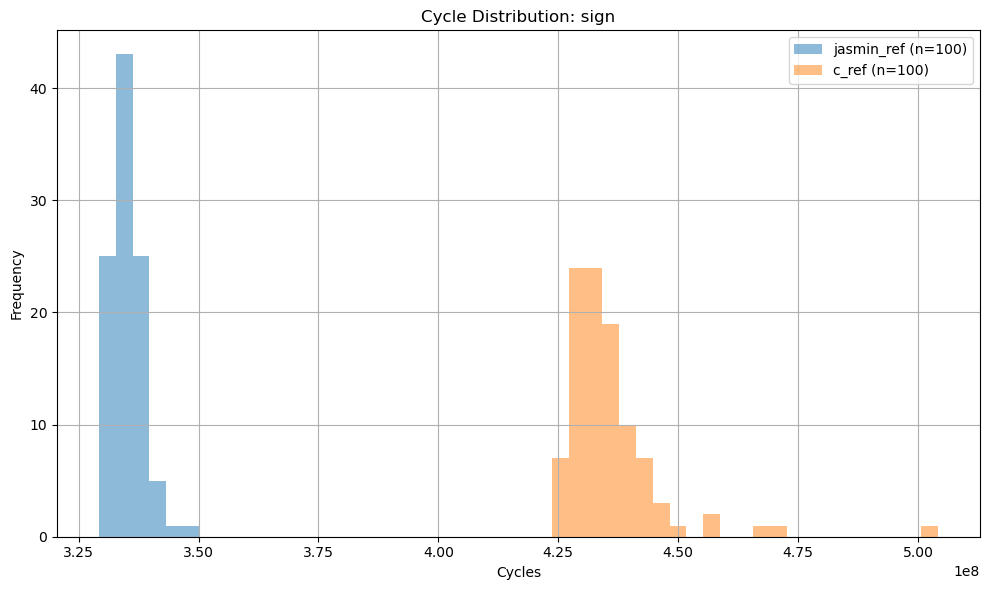

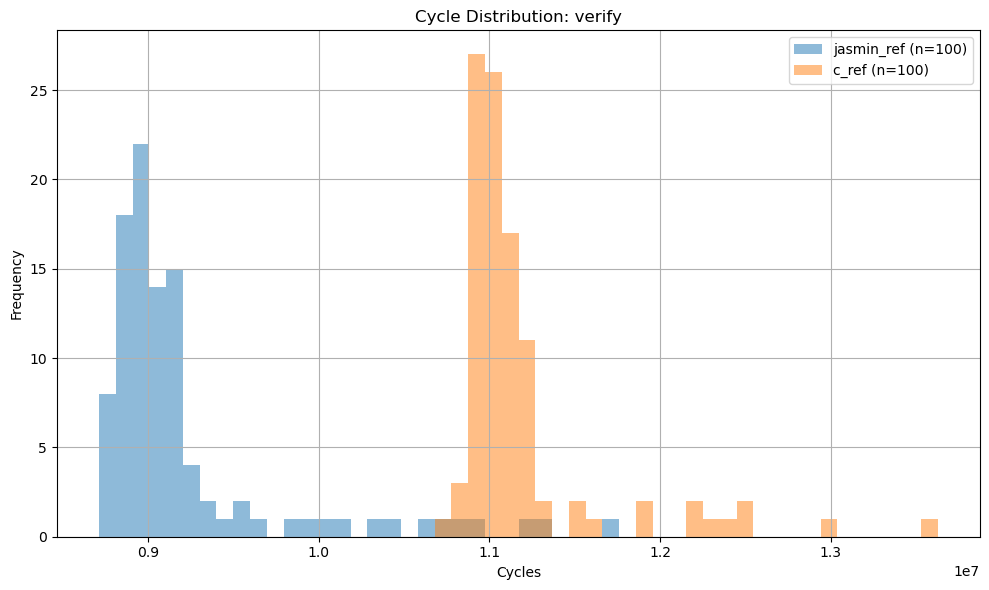

In [5]:
# plot distributions

for action in actions:

    plt.figure(figsize=(10, 6))

    # collect all cycle measurements for this action
    # so both implementations use identical histogram bins

    all_cycles = []

    for impl in implementations:
        if action in benchmark_data.get(impl, {}):
            all_cycles.extend(benchmark_data[impl][action])

    if len(all_cycles) == 0:
        continue

    all_cycles = np.array(all_cycles)

    # create shared bins

    num_bins = 50

    bins = np.linspace(
        all_cycles.min(),
        all_cycles.max(),
        num_bins + 1
    )

    # plot histograms using shared bins

    for impl in implementations:

        if action not in benchmark_data.get(impl, {}):
            continue

        cycles = benchmark_data[impl][action]

        plt.hist(
            cycles,
            bins=bins,
            alpha=0.5,
            density=False,
            label=f"{impl} (n={len(cycles)})"
        )

    plt.xlabel("Cycles")
    plt.ylabel("Frequency")
    plt.title(f"Cycle Distribution: {action}")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [6]:
#print summary statistics

print("\nSummary statistics:\n")

for impl in implementations:
    for action in actions:

        if action not in benchmark_data.get(impl, {}):
            continue

        cycles = benchmark_data[impl][action]

        print(f"{impl:12s} {action:7s}")
        print(f"  measurements : {len(cycles)}")
        print(f"  min          : {cycles.min()}")
        print(f"  max          : {cycles.max()}")
        print(f"  mean         : {cycles.mean():.2f}")
        print(f"  median       : {np.median(cycles):.2f}")
        print(f"  stddev       : {cycles.std():.2f}")
        print()


Summary statistics:

jasmin_ref   keygen 
  measurements : 100
  min          : 16074156
  max          : 19378196
  mean         : 16803505.16
  median       : 16616649.00
  stddev       : 656596.97

jasmin_ref   sign   
  measurements : 100
  min          : 329244636
  max          : 347713841
  mean         : 334976162.04
  median       : 334013974.50
  stddev       : 3364639.35

jasmin_ref   verify 
  measurements : 100
  min          : 8711262
  max          : 11705946
  mean         : 9224676.69
  median       : 9013053.00
  stddev       : 602616.61

c_ref        keygen 
  measurements : 100
  min          : 20789202
  max          : 25636085
  mean         : 21806862.64
  median       : 21387429.00
  stddev       : 967836.18

c_ref        sign   
  measurements : 100
  min          : 424718826
  max          : 504186918
  mean         : 435626458.23
  median       : 433077947.50
  stddev       : 10409669.92

c_ref        verify 
  measurements : 100
  min          : 10755024
  